# Time Series Analysis: Representation

A time series is a sequence of **data points**, usually with equally spaced time intervalls. Time series can grow to enormous size, depending on the observation duration and frequency. So natively, an array holding the time series data can grow indefinetely.

This chapter first shows **normalization** techniques for the data. Then, some time series **representations** which differ from plain arrays are presented. These representations allow more efficient searching, indexing, noise reduction and better memory efficieny.

In [1]:
# packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import meteostat as ms
from datetime import datetime

Let's load some temperature data around bolzano:

In [2]:
bolzano = ms.Point(46.5, 11.35, 262)  

# Get nearby weather stations
stations = ms.stations.nearby(bolzano, limit=1, radius=10000)
station_ids = stations.index.tolist()

start = datetime(2023, 6, 1)
end = datetime(2023, 6, 15)

ms.config.block_large_requests = False
data = ms.hourly(station=station_ids, start=start, end=end, parameters=["temp"])

ts_data = data.fetch().reset_index().pivot(index='time', columns='station', values='temp').squeeze()

count     337.0
mean     20.731
std       4.551
min        12.0
25%        17.0
50%        20.0
75%        24.3
max        30.0
Name: 16020, dtype: Float64


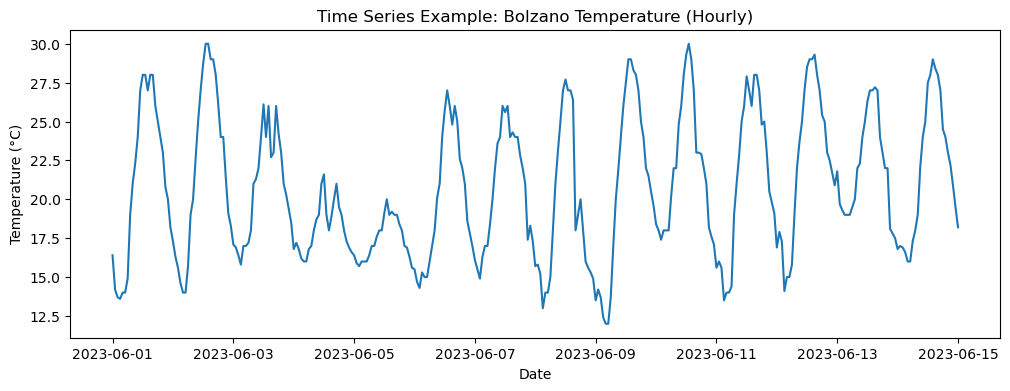

In [3]:
# some statistics of the original time series
print(ts_data.describe().round(3))

# plot of the time series
plt.figure(figsize=(12, 4))
plt.plot(ts_data.index, ts_data.values)
plt.title("Time Series Example: Bolzano Temperature (Hourly)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

## 1. Normalization
As time series can have a difference in values due to the underlying scale or other reasons, normalizing them for comparison can be useful. Two of the most used normalization techniques are min-max and z-normalization. 

**Min-Max-Normalization** uses the min and max values of the time series to fit it into the range of [0,1] with the min always being mapped to 0 and the max to 1. In comparison to z-normalization, mean and standard deviation are not standardised.

In [4]:
def min_max_norm(time_series):
    ts_min = np.min(time_series)
    ts_max = np.max(time_series)
    
    return (time_series - ts_min) / (ts_max - ts_min)

# other options: sklearn.preprocessing.normalize, sklearn.preprocessing.MinMaxScaler
ts_min_max = min_max_norm(ts_data.values)

print(pd.DataFrame(ts_min_max).describe().round(3))

           0
count  337.0
mean   0.485
std    0.253
min      0.0
25%    0.278
50%    0.444
75%    0.683
max      1.0


**Z-Normalization** shifts the time series in a way that makes it have a mean of 0 and a standard deviation of 1. 

When the function is supposed to accept any time series, it is important to handle constant series. They have a standard deviation of 0, which would break the division. One can either check for a constant series in the beginning or add a very small number to the denominator which does not influence regular values too much but is division safe.

In [5]:
def znorm(time_series):
    ts_mean = np.mean(time_series)
    ts_std = np.std(time_series)

    return (time_series - ts_mean) / (ts_std + 1e-8)

# other options: sklearn.preprocessing.normalize, sklearn.preprocessing.StandardScaler
ts_znormed = znorm(ts_data.values)

print(pd.DataFrame(ts_znormed).describe().round(2))

           0
count  337.0
mean    -0.0
std      1.0
min    -1.92
25%    -0.82
50%    -0.16
75%     0.79
max     2.04


Lets compare the two normalizations: Notice, how z-normalization doesn't bound the values per se. Furthermore, we can still observe the bijective property of both normalizations.

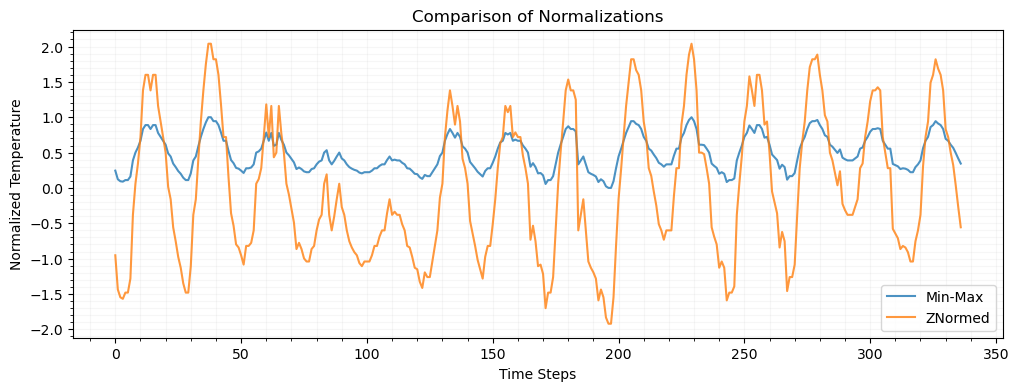

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(ts_min_max, label='Min-Max', alpha=0.8)
plt.plot(ts_znormed, label='ZNormed', alpha=0.8)

plt.title("Comparison of Normalizations")
plt.xlabel("Time Steps")
plt.ylabel("Normalized Temperature")
plt.legend()

plt.minorticks_on()
plt.grid(which="both", alpha=0.1)
plt.show()

## 2. Representation

As time series can grow up to extreme size, representation techniques are getting more and more important. They can allow the time series to be stored more memory efficient (dimensionality reduction) or support different analysation techniques through their structure.

**Important side note: In the following dimensionality reductions, we often keep the removed dimensions as zeros for ease of use. This of course does not reduce the memory size - one had to manage an extra index structure to correctly restore the time series from the remaining dimensions**

From the several shown representation techniques in the lecture, we will implement the following three:
1. DFT (**Discrete Fourier Transformation**)
2. PAA (**Piecewise Aggregate Approximation**)
3. SAX (**Symbolic Aggregate Approximation**)

Additionally, we will extend the section about **wavelets** as they are used later on in the lecture.

### 2.1. DFT

Discrete Fourier Transformation is a way to represent a discrete set of points as a sum of **trigonometric functions**, i.e. sinus and cosinus. The formula for DFT is 

$$X_k = \sum_{n=0}^{N-1} x_n \cdot e^{-i2\pi \frac{k}{N}n}$$

where 
- $X_k$ is a complex number that tells us the amplitude and phase of the k'th frequency
- $\sum_{n=0}^{N-1} x_n$ says that we are aggregating information from all our data points
- $e^{-i2\pi}$ describes that we are using sinoidal functions. It is simply a practical way to express a circle mathematically and directly links to sin and cos.
- $\frac{k}{N}n$ describes the position around the circle in the complex plane for frequency k at time step n

It transforms the input into **complex numbers** which store the contribution of each evaluated **frequency**. A more intuitive insight to Fourier Transform can be gained [here](https://betterexplained.com/articles/an-interactive-guide-to-the-fourier-transform/).

**Fast Fourier Transformation** (FFT) is only an algebraic trick on the DFT formula, because the latter uses several computations multiple times. By efficiently reorganizing those computations, one can lower the runtime from $\mathcal{O}(n^2)$ to $\mathcal{O}(n \log n)$. Because FFT is so widely applied, the term is commenly used interchangeably with DFT.

The first 5 values of the DFT:
(6986.2+0j)
(174.44+219.68j)
(45.49-67.42j)
(-92.55-107.36j)
(-116.18+99.98j)

A snippet of the positive frequencies which were evaluated:
[0.         0.00296736 0.00593472 0.00890208 0.01186944 0.0148368
 0.01780415 0.02077151 0.02373887 0.02670623]


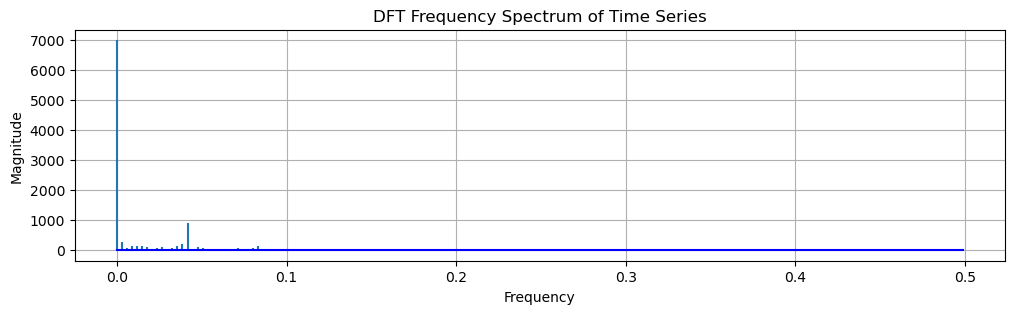

In [24]:
# We are using rfft (real fft) and its associate functions 
# as real world signals usually don't contain complex numbers
from scipy.fft import rfft, rfftfreq, irfft

N = len(ts_data.values)                 # Number of samples in the time series
yf = rfft(ts_data.values)               # Result of the fft
xf = rfftfreq(N, d=1.0)                 # The frequencies which were evaluated

print("The first 5 values of the DFT:")
print(*yf[:5].round(2), sep="\n")

print("\nA snippet of the positive frequencies which were evaluated:")
print(xf[:10])

plt.figure(figsize=(12, 3))
plt.stem(xf, np.abs(yf), markerfmt=" ", basefmt="-b")

plt.title("DFT Frequency Spectrum of Time Series")
plt.grid()
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.show()

Although a clear spike for the most important frequency is observable, one can see some additional frequencies still being considerable for the signal. 

To showcase the Fourier Transform of a clear signal, a time series made up of two sinoidal functions is shown below:

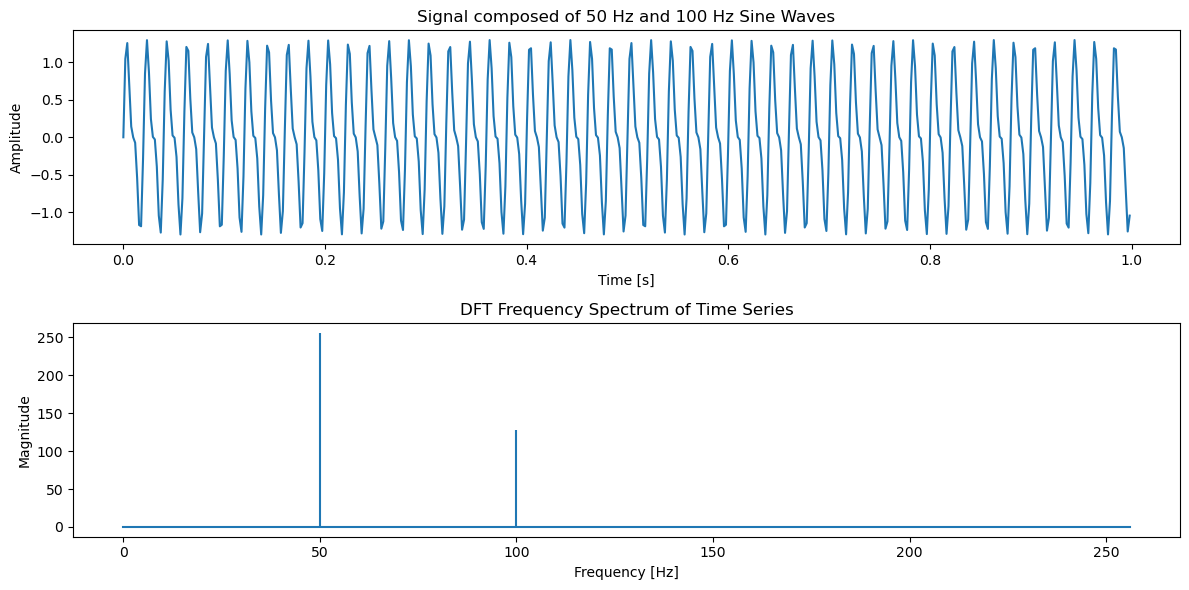

In [22]:
# Play with the time series parameters to see how the DFT changes
n = 512
freq_1 , mag_1 = 50, 1
freq_2 , mag_2 = 100, 0.5

# Data generation
t = np.linspace(0, 1, n, endpoint=False)
wave1 = mag_1 * np.sin(2 * np.pi * freq_1 * t)
wave2 = mag_2 * np.sin(2 * np.pi * freq_2 * t)
signal = wave1 + wave2

# FFT of synthetic signal
signalf = rfft(signal)
xf = rfftfreq(n, d=1.0/n)

# Plotting the synthetic signal and its DFT
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, signal)
plt.title(f"Signal composed of {freq_1} Hz and {freq_2} Hz Sine Waves")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

plt.subplot(2, 1, 2)
plt.stem(xf, np.abs(signalf), markerfmt=" ", basefmt="")
plt.title("DFT Frequency Spectrum of Time Series")
# plt.grid()
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")

plt.tight_layout()
plt.show()

One can observe the clear spikes at the specified frequencies. Furthermore, the set magnitude of the frequencies remains proportional in the frequency spectrum.

In order to reduce the dimensions of the signal, we can filter for the most important frequencies by their magnitude. A small subset of the frequencies 

In [11]:
def reduce_dims_fft(yf, dims):
    # 1: get the contribution of each frequency
    magnitudes = np.abs(yf)

    # 2: Find the indices of the top N dominant frequencies
    freqs_to_keep = dims 
    top_indices = np.argsort(magnitudes)[-freqs_to_keep:]

    # 3: Create a filtered FFT array (zeroing out the rest)
    yf_reduced = np.zeros_like(yf)
    yf_reduced[top_indices] = yf[top_indices]

    return yf_reduced

From these we can simply recreate a signal with the inverse FFT. If frequencies have been removed, the signal often loses some of its complexity. 

The first value in the FFT ($k=0$) is the DC-Term, which represents the sum of the time series (try plugging 0 into the DFT formula). Because raw data often fluctuates above zero, the DC term is frequently the largest value in the spectrum. The term "direct current" (DC) stems from electrical engineering, where DC provides a constant, flat voltage. In Fourier Transformation, this value acts as the baseline offset of the data, allowing us to restore the original vertical level of the signal.

The first plot shows a reconstructed signal keeping only the two largest magnitudes (usually the DC-Term to establish the baseline, plus the most dominant oscillating frequency). The other three plots show progressively more frequencies included in the reduced signal, drawing them closer to the original time series. Keeping all frequencies would result in a perfect inversion.

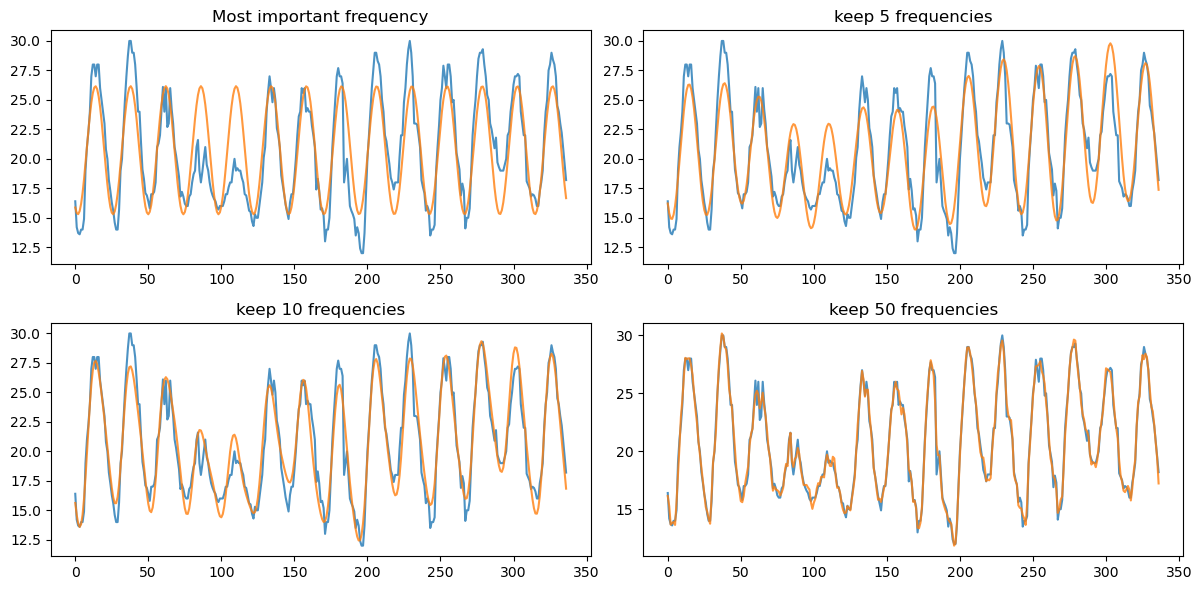

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.plot(ts_data.values, alpha=0.8)
plt.plot(irfft(reduce_dims_fft(yf, 2), n=N), alpha=0.8)
plt.title("Most important frequency")

plt.subplot(2, 2, 2)
plt.plot(ts_data.values, alpha=0.8)
plt.plot(irfft(reduce_dims_fft(yf, 5), n=N), alpha=0.8)
plt.title("keep 5 frequencies")

plt.subplot(2, 2, 3)
plt.plot(ts_data.values, alpha=0.8)
plt.plot(irfft(reduce_dims_fft(yf, 10), n=N), alpha=0.8)
plt.title("keep 10 frequencies")

plt.subplot(2, 2, 4)
plt.plot(ts_data.values, alpha=0.8)
plt.plot(irfft(reduce_dims_fft(yf, 50), n=N), alpha=0.8)
plt.title("keep 50 frequencies")

plt.tight_layout()
plt.show()

### 2.2. PAA

Piecewise Aggregate Approximation **averages** the values within each **tumbling window**. PAA can be implemented either by specifying a window size or the number of PAA segments wanted, as one easily translates to the other.

The window size controls how many data points are averaged at once. This implementation uses the number of segments.

In [13]:
# or use pyts.pproximation.PiecewiseAggregateApproximation
def paa(X, n_segments):
    # 1: Split array into number of segments
    segments = np.array_split(X, n_segments)
    segment_lengths = [len(chunk) for chunk in segments] # Store segment lengths for X % n_segments != 0

    # 2: Calculate the mean within each window
    X_paa = np.empty(n_segments)
    for j, segment in enumerate(segments):
        X_paa[j] = np.mean(segment)
        
    return X_paa, segment_lengths

Lets look at some window sizes to see how they affect the PAA function. One can observe the correlation between saved memory and precision loss:

Keeping only 2 segments is a massive dimensionality reduction but looses most of the signal.
Keeping 50 segments resembles the time series already pretty well and requires still only 1/7 of the original signal dimensions. 

One always has two find the right amount of reduction to support the respective goal.

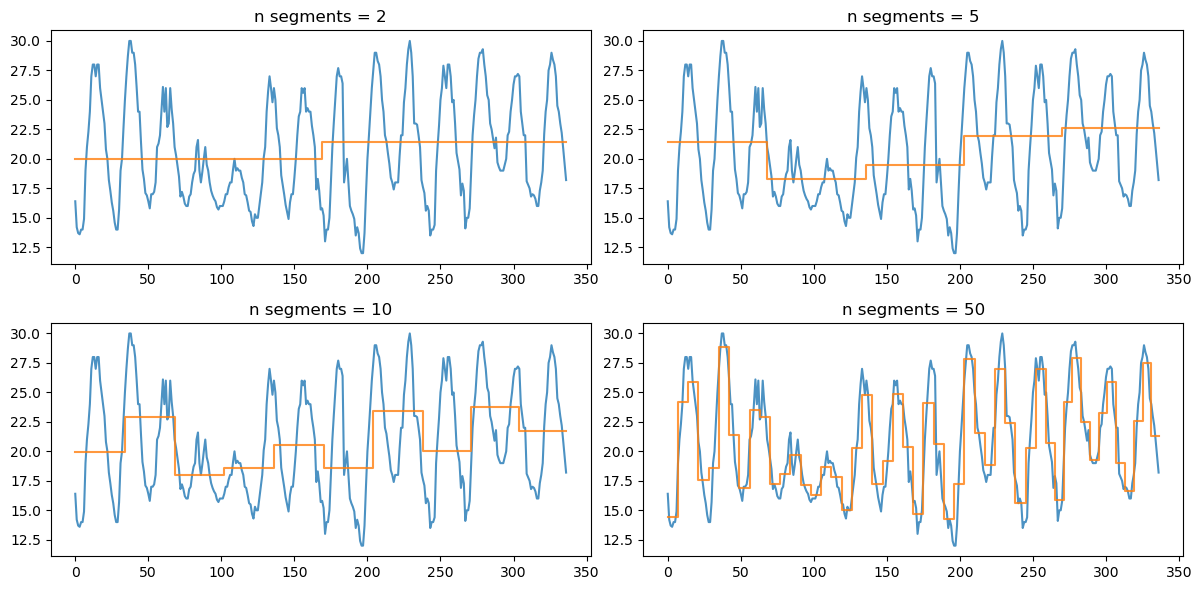

In [14]:
ts_paa_2, paa_len_2 = paa(ts_data, 2)
ts_paa_5, paa_len_5 = paa(ts_data, 5)
ts_paa_10, paa_len_10 = paa(ts_data, 10)
ts_paa_50, paa_len_50 = paa(ts_data, 50)

plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.plot(ts_data.reset_index(drop=True), alpha=0.8)
plt.plot(np.repeat(ts_paa_2, paa_len_2), alpha=0.8, drawstyle='steps-post')            # we have to repeat each value to get to the original length
plt.title("n segments = 2")

plt.subplot(2, 2, 2)
plt.plot(ts_data.reset_index(drop=True), alpha=0.8)
plt.plot(np.repeat(ts_paa_5, paa_len_5), alpha=0.8, drawstyle='steps-post')            # we have to repeat each value to get to the original length
plt.title("n segments = 5")

plt.subplot(2, 2, 3)
plt.plot(ts_data.reset_index(drop=True), alpha=0.8)
plt.plot(np.repeat(ts_paa_10, paa_len_10), alpha=0.8, drawstyle='steps-post')            # we have to repeat each value to get to the original length
plt.title("n segments = 10")

plt.subplot(2, 2, 4)
plt.plot(ts_data.reset_index(drop=True), alpha=0.8)
plt.plot(np.repeat(ts_paa_50, paa_len_50), alpha=0.8, drawstyle='steps-post')          # we have to repeat each value to get to the original length
plt.title("n segments = 50")

plt.tight_layout()
plt.show()

**Comparing PAA to DFT:**

Because the data follows a clear periodic pattern, the DFT with its sinoidal functions seems better fitted to the data than PAA given the same dimensionality reduction. 

However, unperiodic time series, e.g. a linear function, are arguably easier reduced in PAA than DFT.

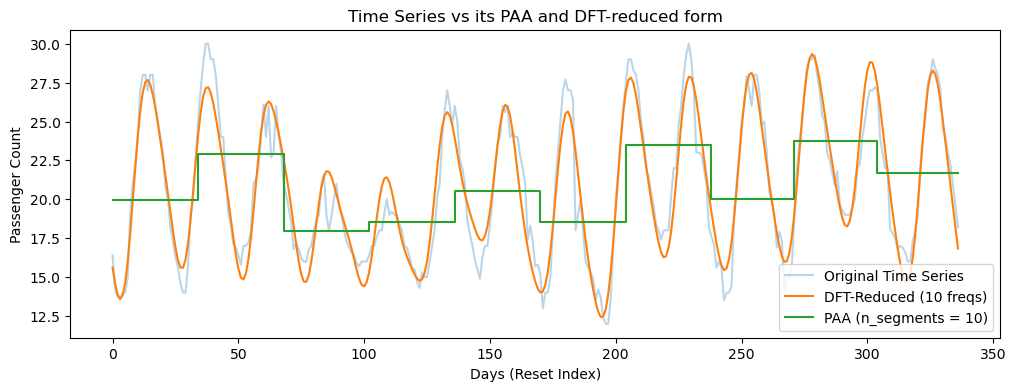

In [15]:
n_dims = 10

plt.figure(figsize=(12, 4))
plt.plot(ts_data.reset_index(drop=True), label="Original Time Series", alpha=0.3)
plt.plot(irfft(reduce_dims_fft(rfft(ts_data.values), n_dims), n=N), label=f"DFT-Reduced ({n_dims} freqs)") # TS -> DFT -> Reduce -> Reverse
ts_paa, paa_lens = paa(ts_data, n_dims)
plt.plot(np.repeat(ts_paa, paa_lens), label=f"PAA (n_segments = {n_dims})", drawstyle='steps-post')

plt.title("Time Series vs its PAA and DFT-reduced form")
plt.xlabel("Days (Reset Index)")
plt.ylabel("Passenger Count")
plt.legend()
plt.show()

### 2.3. SAX

Symbolic Aggregate Approximatio (SAX) is an evolution of PAA. It takes the averaged **PAA** segments and maps them to discrete characters/**symbols** (a, b, c...) based on Gaussian probability bins. These bins are used as we are trying to make each letter appear equally likely. This way, no single symbol dominates the SAX.

SAX allows specifying the number of segments (word length) and number of symbols:

In [16]:
import string
from scipy.stats import norm

# or use pyts.approximation.SymbolicAggregateApproximation
def sax(X, n_segments, n_bins, return_paa=False):
    # 1: Prepare symbols
    alphabet = list(string.ascii_lowercase)
    bins = np.array(alphabet[:n_bins]) # Converted to numpy array for fast indexing

    # 2: Perform PAA to get averaged results
    X_paa, chunk_lengths = paa(X, n_segments)
    
    # 3: Calculate equiprobable breakpoints using the normal distribution
    breakpoints = norm.ppf(np.linspace(0, 1, n_bins + 1)[1:-1])

    # 4: Convert values into letters
    indices = np.searchsorted(breakpoints, X_paa.copy(), side='left')  # map value to a bin index
    sax_symbols = bins[indices]                                        # use indices to fetch the corresponding letters

    if return_paa:
        return np.array(sax_symbols), X_paa, chunk_lengths # for plotting
    else:
        return np.array(sax_symbols)

Now we are able to create the SAX from the time series. The SAX algorithm assumes a z-normalized input.



The resulting SAX String:
bbcbaaabbbbaccbbccac


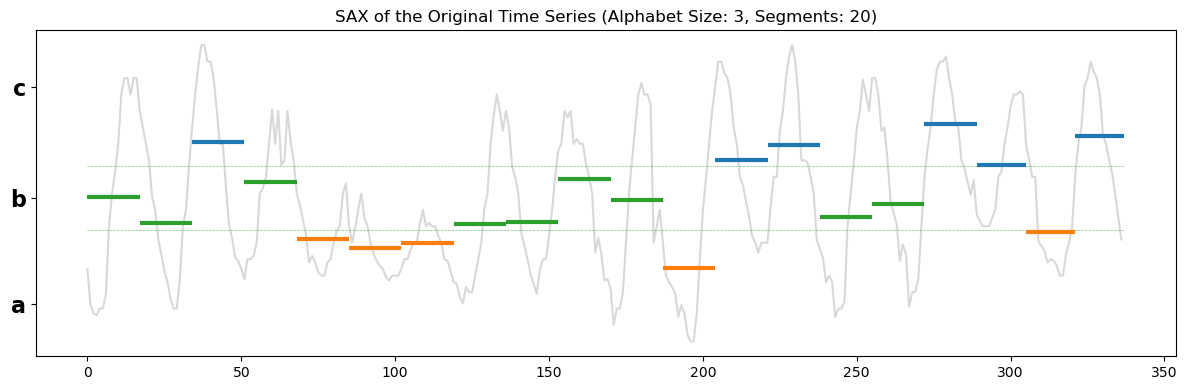

In [32]:
n_bins = 3
n_segments = 20 # Replaced window_size

# Assuming your sax function is now updated to take n_segments
X_sax, X_paa, paa_lens = sax(znorm(ts_data.values), n_segments=n_segments, n_bins=n_bins, return_paa=True)

# print the SAX string
print("The resulting SAX String:")
print("".join(X_sax))

# plot SAX on original time series
plt.figure(figsize=(12, 4))
plt.plot(znorm(ts_data.values), alpha=0.3, color='gray')

# Draw the horizontal bin thresholds
bins = norm.ppf(np.linspace(0, 1, n_bins + 1)[1:-1])
plt.hlines(bins, 0, len(ts_data.values), color='g', linestyles='--', linewidth=0.5, alpha=0.5)

# --- THE FIX: Calculate exact start and end points for variable-length segments ---
x_maxs = np.cumsum(paa_lens)                       # Ends: [len1, len1+len2, len1+len2+len3...]
x_mins = np.concatenate(([0], x_maxs[:-1]))        # Starts: [0, len1, len1+len2...]

cmap = plt.get_cmap('tab10')

# Draw the colored PAA segments
plt.hlines(X_paa, 
           x_mins, 
           x_maxs,
           colors=[cmap(ord(char) % n_bins) for char in X_sax],
           linewidth=3 # Made slightly thicker so the colors pop
           )

# Format the Y-axis to show the SAX letters (a, b, c...) inside the bins
y_min = znorm(ts_data.values).min() - 0.5
y_max = znorm(ts_data.values).max() + 0.5

extended_bounds = np.concatenate(([y_min], bins, [y_max]))
bin_centers = (extended_bounds[:-1] + extended_bounds[1:]) / 2
plt.yticks(ticks=bin_centers, labels=np.unique(list(X_sax)), fontsize=16, fontweight='bold')

plt.title(f"SAX of the Original Time Series (Alphabet Size: {n_bins}, Segments: {n_segments})")
plt.tight_layout()
plt.show()

### 2.4. Additional: Wavelets

Wavelet Transform follows a similar idea to Fourier Transform: **Transforming** a time series into a sum of different shapes - those shapes being sinoidal waves for Fourier and so called wavelets for wavelet transform. There is also a discrete version (DWT) to deal with samples instead of continuous signals. DWT returns a list of **coefficients** in the wavelet domain.

A nice description of wavelets can be found [here](https://brendanjameslynskey.github.io/WaveletTransformGuide/).

While DFT contains information about the **frequency**, it does not contain any **temporal** information. DWT captures both frequency and time, but at a lower frequency resolution. In fact, it is impossible to capture both perfectly simultaneously. 

Comparable to DWT is short-time Fourier transform (STFT) which tries to capture temporal information by performing DFT on subsequences of the time series.

Wavelet Transform is based on a **mother wavelet** and its derived **levels**. To count as a wavelet, a function has to fulfill some mathematical properties which makes it a basis for the Hilbert Space. Such a wavelet is then "moved" along the time series and the respective **correlation** is captured (often computed via **convolution**).

The formula for DWT is $$W(j,k) = \sum_{n=0}^{N-1} x(n) \psi_{j,k}(n)$$ with
* $W(j,k)$ being the detail coefficient, stating how strong the time series matches the wavelet that has been stretched/squeezed by amount j and shifted across the timeline by amount k
* $\sum_{n=0}^{N-1}$ aggregating the results over the whole time series
* $x(n)$ is the current data point
* $\psi_{j,k}(n)$ is the respective wavelet

To derive higher level wavelets from the mother wavelet, the following formula is applied: $$\psi_{j,k}[n] = 2^{j/2}\psi (2^jn-k)$$ with
* $\psi_{j,k}[n]$ is the wavelet that has been stretched/squeezed by amount j and shifted across the timeline by amount k
* $j$ is the level and controls the "compression" of the wavelet
* $k$ shifts the wavelet across the x-axis
* $\frac{1}{\sqrt{2^j}}$ normalizes the energy of the wavelet that changes during compression. It assures a fair weighting between the wavelet levels.

The easiest (and first found) wavelet is the **Haar wavelet** shown below:

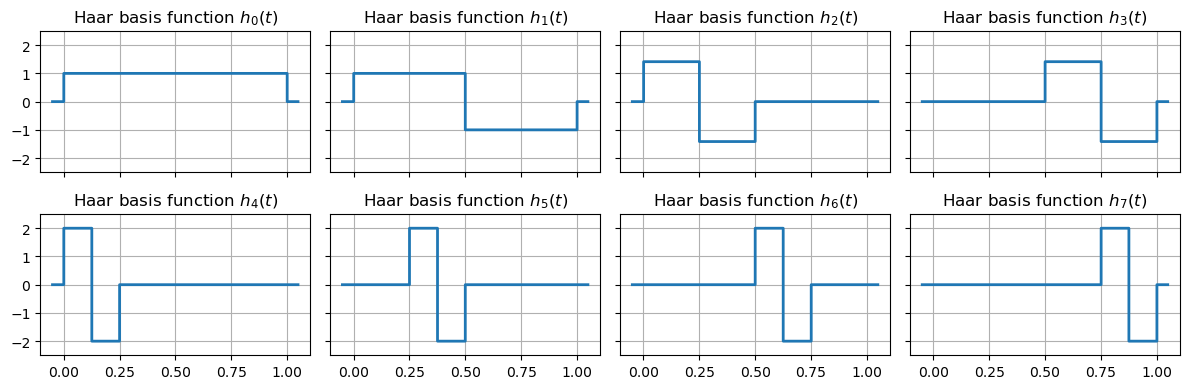

In [33]:
def haar(level, t):
    if level == 0: 
        return np.where((t >= 0) & (t < 1), 1.0, 0.0) # Scaling function
        
    j = int(np.log2(level))        # Scale
    k = level - 2**j               # Shift
    
    # Mother wavelet scaled and shifted
    return (2**(j/2)) * np.where((2**j * t >= k) & (2**j * t < k + 0.5), 1,
                        np.where((2**j * t >= k + 0.5) & (2**j * t < k + 1), -1, 0))

# Time vector
t = np.linspace(-0.05, 1.05, 1000, endpoint=False)

# Plotting in a 2x3 grid
fig, axes = plt.subplots(2, 4, figsize=(12, 4), sharex=True, sharey=True)

for i, ax in enumerate(axes.flat):
    ax.plot(t, haar(i, t), drawstyle='steps-post', lw=2)
    ax.set_title(f'Haar basis function $h_{i}(t)$')
    ax.set_ylim(-2.5, 2.5)
    ax.grid(True)

plt.tight_layout()
plt.show()

Again similar to DFT, computing the original formula for each time point is not feasable. 

Instead, (S.G. Mallat, 1989) showed that one can define a **low and high pass filter** to slide over the data which creates an equal result but is computed way faster in $\mathcal{O}(n)$. The filters for Haar wavelets are very simple: taking the **average** (low-pass filter) and the **difference** (high-pass filter) between adjacent data points:

In [35]:
def dwt_haar(x):    
    # 1. Define the Haar filters
    L = np.array([1, 1]) / np.sqrt(2)   # Low-pass (Scaling filter)
    H = np.array([1, -1]) / np.sqrt(2)  # High-pass (Wavelet filter)
    
    coeffs = []
    approx = x
    
    while len(approx) > 1:
        # 2. Filtering (Cross-Correlation)
        filtered_approx = np.correlate(approx, L, mode='valid')
        filtered_detail = np.correlate(approx, H, mode='valid')
        
        # 3. Decimation (Downsampling by 2)
        # The correlation computed overlapping pairs: (x0, x1), (x1, x2), (x2, x3)...
        # Because Haar is an orthogonal basis, we don't want overlapping windows.
        # We keep only every 2nd value to isolate: (x0, x1), (x2, x3), (x4, x5)...
        next_approx = filtered_approx[::2]
        detail = filtered_detail[::2]
        
        # Store the detail and pass the approximation to the next level
        coeffs.append(detail)
        approx = next_approx
        
    coeffs.append(approx)
    
    return coeffs[::-1]

We truncate the data length to a power of two. This ensures the dyadic downsampling (dividing the array in half at each level) works perfectly without needing to pad the boundaries.

Because DWT is a transform, the total number of coefficients across all levels exactly equals the original time series length. The very first coefficient represents the global average (the macro trend). As we move from the coarsest details to the finest details, the number of coefficients in each level doubles.

The plot below shows the coefficients of the finest Haar level. At this resolution, the wavelet has a filter length of just 2, meaning it captures the difference between immediately adjacent data points. Because it evaluates the data in pairs, this specific level contains exactly half as many coefficients as the original time series.

Global Average: [324.1625]
Lengths of coefficient list for each level: [1, 1, 2, 4, 8, 16, 32, 64, 128] -> number of coefficients is same as time series length
E.g. first few coeffs: [array([-10.125]), array([18.58806951, -3.77418244]), array([-11.0125,   8.8   ,   7.35  ,  -6.8625])]


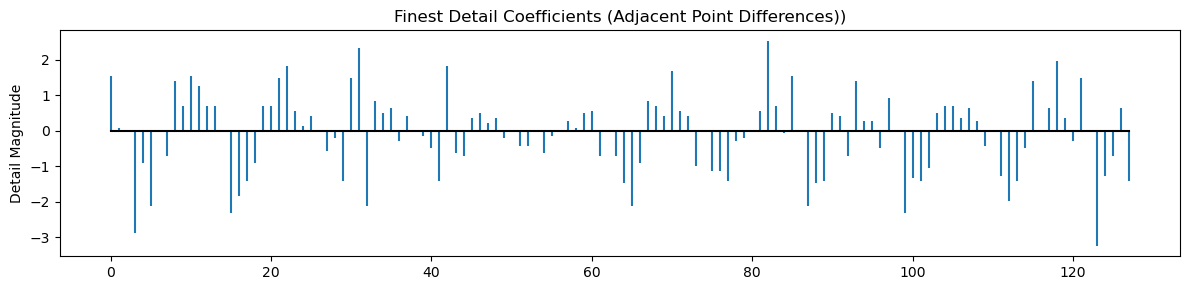

In [ ]:
# Cutting data length to a power of two
dwt_data = ts_data.copy().to_numpy()[:256]
haar_coeffs = dwt_haar(dwt_data)

# Showcase some properties
print(f"Global Average: {haar_coeffs[0]}")
print(f"Lengths of coefficient list for each level: {[len(level) for level in haar_coeffs]} -> number of coefficients is same as time series length")
print(f"E.g. first few coeffs: {haar_coeffs[1:4]}")

plt.figure(figsize=(12, 3))
plt.stem(haar_coeffs[-1], markerfmt=" ", basefmt="-k") # Highest level: The Finest Details (Micro Features)
plt.title("Finest Detail Coefficients (Adjacent Point Differences))")
plt.xlabel("")
plt.ylabel("Detail Magnitude")
plt.tight_layout()
plt.show()

As DWT is a transform, the number of dimension stays the same. To reduce the dimensionality, we can filter for the coefficients of the DWT with the biggest magnitude. Similar to DFT, most information about the signal is stored in only a few coefficients.

To perform the inverse transform, i.e. going from the DWT coefficients back to the signal, the items can be passed through inverse filters for each level.

In [49]:
def reduce_dims_dwt(coeffs, k):
    # 1. Flatten all coefficient arrays into one giant 1D array
    all_values = np.concatenate([c.flatten() for c in coeffs])
    
    # 2. Find the threshold magnitude of the k-th largest value
    if k >= len(all_values):
        return coeffs  # Ask to keep more than we have? Change nothing.
    
    threshold = np.sort(np.abs(all_values))[-k]
    
    # 3. Rebuild the list, zeroing out anything below the threshold
    filtered_coeffs = []
    for c in coeffs:
        # np.where(condition, value_if_true, value_if_false)
        thresholded_array = np.where(np.abs(c) >= threshold, c, 0.0)
        filtered_coeffs.append(thresholded_array)
        
    return filtered_coeffs

def inverse_dwt_haar(coeffs):
    approx = coeffs[0]

    for detail in coeffs[1:]:
        # 1. Reverse the math: Rebuild the left and right items
        left_items = (approx + detail) / np.sqrt(2)
        right_items = (approx - detail) / np.sqrt(2)
        
        # 2. Create an empty array twice the size to hold the new sequence
        next_approx = np.empty(len(left_items) + len(right_items), dtype=float)
        
        # 3. Interleave them back together using slicing
        next_approx[0::2] = left_items   # Put left items in even indices (0, 2, 4...)
        next_approx[1::2] = right_items  # Put right items in odd indices (1, 3, 5...)
        
        # Pass the expanded array forward to the next level
        approx = next_approx
        
    return approx

The following plots show the original time series against its **reconstructed** form after **dimensionality reduction** using DWT.

Similar to our DFT approach, we reduce dimensions by keeping only the top $k$ wavelet coefficients with the largest absolute **magnitudes** and setting the rest to zero.

Because our temperature data fluctuates well above zero, the first level (the approximation coefficient) has a massive magnitude and is naturally kept. Just like the DC-Term in the Fourier Transform, it holds the global average and is necessary to restore the baseline vertical level of the data.

The first plot keeps only 2 coefficients: the approximation (to set the baseline) and the single largest detail coefficient. Thus, it visually highlights the exact position and compression level where a Haar wavelet matched the time series the best. The subsequent plots keep progressively more coefficients, allowing finer, high-frequency details to re-emerge.

As with DFT, keeping all coefficients would result in a perfectly restored signal.

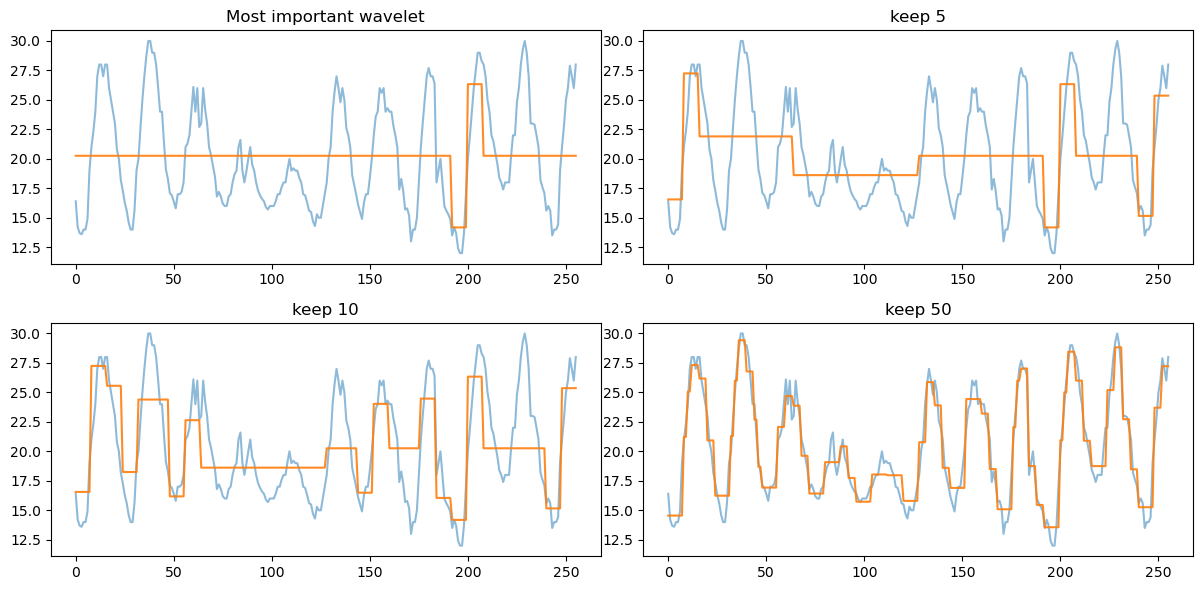

In [51]:
# Plotting dimensionality reduced time series with haar_coeffs from above
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.plot(dwt_data, alpha=0.5)
plt.plot(inverse_dwt_haar(reduce_dims_dwt(haar_coeffs, 2)), alpha=0.9)
plt.title("Most important wavelet")

plt.subplot(2, 2, 2)
plt.plot(dwt_data, alpha=0.5)
plt.plot(inverse_dwt_haar(reduce_dims_dwt(haar_coeffs, 5)), alpha=0.9)
plt.title("keep 5")

plt.subplot(2, 2, 3)
plt.plot(dwt_data, alpha=0.5)
plt.plot(inverse_dwt_haar(reduce_dims_dwt(haar_coeffs, 10)), alpha=0.9)
plt.title("keep 10")

plt.subplot(2, 2, 4)
plt.plot(dwt_data, alpha=0.5)
plt.plot(inverse_dwt_haar(reduce_dims_dwt(haar_coeffs, 50)), alpha=0.9)
plt.title("keep 50")

plt.tight_layout()
plt.show()

One can observe how the most important feature of wavelets is used: The utilization of the time domain instead of just the frequency domain (as in Fourier Transform). The wavelet is applied at a position where the time series matches it the most.

## 3. Exercises

### 3.1. More Representations

Implement Piecewise Linear Approximation PLA or Adaptive Piecewise Constant Approximation (APCA) from the lecture.

- PLA uses line segments to approximate the time series.
- APCA uses averages of data segments, but allows the segments to be of different length. [You can also read the APCA paper](https://doi.org/10.1145/568518.568520).

In [ ]:
def pla(time_series, n_segments):
    """
    Piecewise Linear Approximation.
    
    Hints:
    1. Split the time series into `n_segments` (similar to PAA).
    2. For each segment, use np.polyfit(x, y, 1) to find the slope and intercept.
    3. Reconstruct the line for that segment using the slope and intercept.
    """

    # YOUR CODE HERE

    pass # Array of the line segments

def apca(time_series, error_threshold):
    """
    Adaptive Piecewise Constant Approximation.
    
    Hints:
    1. Start with the whole time series as one segment.
    2. If the variance/error in the segment exceeds the `error_threshold`, 
       split it in half.
    3. Recursively repeat until all segments are below the error threshold.
    4. Return the segment averages and their respective lengths.
    """

    # YOUR CODE HERE

    pass # Array of APCA values and array of segment lengths

### 3.2. Detrending
Detrend a time series. You can use `scipy.signal.detrend` or fit a linear regression model and substract the line from the data, e.g. `np.polyfit`.

Or you can use differencing, which gives the differences between adjacent values.

In [ ]:
def differencing(time_series):
    """
    Apply differencing to the time series

    Hints:
    - Store a shifted version of the time series by one index
    - Substract it from the original
    """

    # YOUR CODE HERE

    pass # return differenced time series

def detrend_time_series(time_series):
    """
    Removes the global linear trend from a time series.
    
    Hints:
    - Method A: Use np.polyfit to fit a 1st-degree polynomial to the whole series, 
      create the trend line, and subtract it from the original series.
    - Method B: Use scipy.signal.detrend directly.
    """

    # YOUR CODE HERE
    
    pass # Time Series without trend

In [ ]:
query = None # Specify the query
detrend_ts = detrend_time_series(query)

plt.figure(figsize=(12, 3))
plt.plot(query, label="Original TS")
plt.plot(detrend_ts, label="Detrended TS")
plt.legend()
plt.tight_layout()
plt.show()

### 3.3. More Wavelets

The haar wavelet is the simplest form of a wavelet (using a step function). As many real world signals follow smoother shapes, different wavelet families can be more fitting to the data. Examples are the Daubechies or Morlet wavelet families, but 

Install `pywt` (PyWavelets) and use its wavelet implementations to perform DWT. You can use `pywt.wavedec` for DWT.

In [ ]:
# pip install PyWavelets OR conda install pywavelets
# import pywt

def dtw_daubechies(time_series):
    """
    Applies the Daubechies wavelet transform to the time series.
    
    Hints:
    1. Look up the documentation for `pywt.wavedec`.
    2. Pass in your time series and the wavelet name ('db4' is a standard choice).
    3. The function returns a list of coefficients. The first array in the list 
       contains the approximation coefficients.
    """

    # YOUR CODE HERE

    pass # return coefficients

def dtw_yet_another_wavelet(time_series):
    """
    Research another wavelet in pywt.families and apply it to the data
    """

    # YOUR CODE HERE

    pass # return coefficients